---
title: Linear Algebra
short_title: Vector operations

numbering:
  headings: false

numbered_references: false
---

This chapter will help you get consolidate your knowledge of linear algebra. To solve the exercises in this section you will need to have some basic understanding of:

- numpy arrays
- loops and if statements
- functions


# What is Linear Algebra

>"The heart of linear algebra is in two operations - both with vectors. We add vectors to get *v + w*. We multiply them by numbers *c* and *d* to get *cv* and*dw*. Combining those two operations (adding *cv* to *dw*) gives the linear combination *cv + dw*" 
>
> -- {cite}`Strang`[p.1]

An arrow in a plane is often used as a simple representation of a vector. Using two orthogonal axis *x* and *y* (i.e., angled with 90 degrees), one can describe such vector as a pair of coordinates *(a, b)*, with *a* representing the coordinate in *x*, and *b* representing the coordinate in *y*. The vector can then be drawn from the origin - the point (0,0) - to the point (a,b). 

Such a vector is said to exist in a two-dimensional plane, because it has two coordinates (a and b). However, once one goes beyond the arrow and plane analogy, nothing limits the amount of dimensions of a vector: (1,4,5) is a three-dimensional vector, (5,2,-6,2) is a four-dimensional vector, and so on.

When translating vector coordinates to programming, one can think of different ways to store them. For instance, tuples and lists satisfy the need of storing multiple elements in an ordered fashion. However, arrays are specially suited for that because they are built in a way that optimizes the two operations discussed above, and the operations that derive from them. Thus, in Python, linear combinations are often computed using arrays, specifically with the Numpy module (imported as *np*). Because of that, from here on whenever we use the terms array, the reader should assume we refer to numpy arrays.

Note also that there is a key distinction when talking about arrays in the context of a computer program and vectors in the context of algebra. For instance, we might use the (numpy) array `a = np.array([1,3,5])` to represent the three-dimensional vector (1,3,5). However, the variable `a`, in this case, is said to be a (numpy) array of one dimension. This is so, because the indices of that array can be arranged in a line. 

This distinction between arrays in the context of a computer program, and vectors and matrix in the context of linear algebra also extends to the concept of lenght of an array or vector. For instance, the length of the two-dimensional (2D) vector a with coordinates (3,4) can be calculated using pitagoras theorem to find the hipothenusa of the triangle formed by the vertices $(0,0)$, $(3,0)$, $(3,4)$: 

$h = \sqrt{(a^2 + b^2)}$

with $a=3$ and $b=4$, we have that the length (also known as the module of the vector) of that vector is $h = \sqrt{(3^2 + 4^2)} = 5$.

On the other hand, the length of the array `a = np.array(3,4)` can be retrieved by the calling function `len(a)`, and in this case is 2, which is the number of elements in the array. (The length of the array is actually equivalent to the dimension of the vector) 

```python
a = np.array(3,4)
len(a)
```

Because of that, in the rest of this section we make an explicit distinction between the words "vector" and "array". With vectors (and matrices) being used in the context of linear algebra as explained above, and arrays in the context of programming.


---

## Exercise 1

Write a function *`plot_vector()`* that receives an array containing a 2D vector as a parameter (the length of the array should be 2, then!) and a plot axis, and plots the vector stored in the array in the respective axis. 

::::{dropdown} Hint
You can try to use the function `plt.quiver()` to get something similar to the figure below, but it's also possible to just plot the vector as lines, using `plt.plot()` 
::::


```python
import matplotlib.pyplot as plt
import numpy as np

a = np.array(3,4)
b = np.array(-5,6)

fig, ax = plt.subplots()
plot_vector(ax, a)
plot_vector(ax, b)
plt.xlim((-16,16))
plt.ylim((-10,16))
plt.show()

```

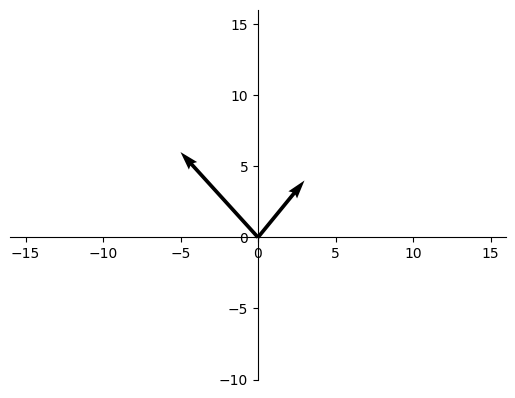

In [63]:
import matplotlib.pyplot as plt
import numpy as np
def plot_vector(ax, arr, c = 'k'):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    if len(arr)==2:
        # plt.plot([0,arr[0]],[0,arr[1]], c)
        plt.quiver([0], [0], [arr[0]], [arr[1]], angles='xy', scale_units='xy', scale=1, color=c)
                        
    else:
        return


a = np.array([3,4])
b = np.array([-5,6])

fig, ax = plt.subplots()
plot_vector(ax, a)
plot_vector(ax, b)
plt.xlim((-16,16))
plt.ylim((-10,16))
plt.show()

In [ ]:
def plot_vector(arr, ax):
  # Your code goes here:

  return

## Exercise 2

Write the function *`vector_length()`* that receives an array `a` as a parameter and returns the length/module of the vector stored in `a`. Your function should work for vectors of any dimension greater or equal than 2. 

In [ ]:
def vector_length(a):
  # Your code goes here:





  return


# Dot product 

The dot product is an operation between two vectors of the same dimension and results in a number or scalar (often this operation is also called the scalar product, or the inner product between the two vectors).

One way of computing the dot product is using the individual coordinates of each vector. For instance, the dot product between two 2D arrays $v = (v_1,v_2)$ and $w = (w_1,w_2)$ can be computed using the following formula:


$v \cdot w = v_1 w_1 +  v_2 w_2$

This can be generalized to N dimensions as:

$v \cdot w = \sum_{i=1}^{n} v_i w_i$

## Exercise 3

Write a function `dot_product()` that receive two arrays representing N-dimensional vectors and returns the dot product between the arrays.


In [ ]:
def dot_product(arr1, arr2):
    # Your code goes here:


    return

There is another way to compute the dot product between two vectors, by using the geometrical interpretation of what is this operation. Given the two vectors $v$ and $w$, the dot product can also be computed using the following formula:

$$v\cdot w = |v||w|cos(\theta _{vw})$$ (dot_product2)

Where $|~|$ is the module operation, which returns the length of a vector, and $\theta$ is the angle between the two vectors. 

This new formula allow us to understand the inner product in a geometrical way because the quantity $|w|cos(\theta _{vw})$ is the "projection" of the vector w in the axis of v (analogously, $|v|cos(\theta _{vw})$ is the projection of the vector v in the axis of w). To visualize this quantity, one can see the "shadow" that w projects into v as depicted in red in the figure below, where $w = (3,4)$ and $v = (8,2)$. 

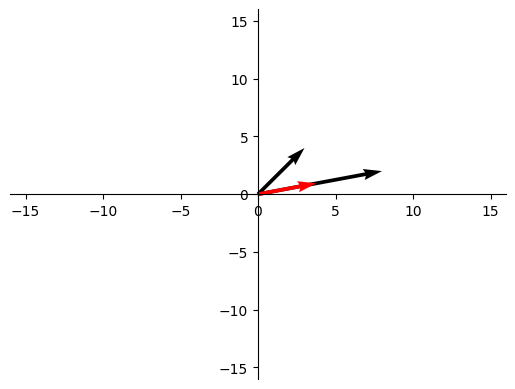

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import math


a = np.array([3,4])
b = np.array([8,2])

a_u = a/np.linalg.norm(a)
b_u = b/np.linalg.norm(b)
angle = np.arccos(np.clip(np.dot(a_u, b_u), -1.0, 1.0))
c = b/np.linalg.norm(b)*np.linalg.norm(a)*np.cos(angle)

fig, ax = plt.subplots()
plot_vector(ax, a)
plot_vector(ax, b)
plot_vector(ax, c, 'r')
plt.xlim((-16,16))
plt.ylim((-16,16))
plt.show()

Hence, following the formula in {eq}`dot_product2`, the dot product between v and w is *the length of v* (or $|v|$) multiplied by *the length of the projection of w in v* (red arrow). 

:::dropdown Orthogonal vectors

From the formula above, one can see that any pair of orthogonal vectors (i.e., that have an angle of 90 degrees) always have the dot product equals to zero, since $cos(90\deg) = 0$. In other words, orthogonal vectors do not share any projection into each other. 

This can be useful to understand how techniques like principal component analysis (PCA) work. For instance, because PCA finds axes that maximize the variance of the data while keeping them orthogonal to each other, each principal component (i.e., each axis after the PCA) captures variance in a direction that has no projection in the other directions. This can be seen by computing the correlation between the points in any two principal components, which should be zero or irrelevant (hence, the principal components are uncorrelated). 
:::

## Exercise 4

Write a function `angle()` that receive two arrays representing N-dimensional vectors and returns the angle between them. Use the functions implemented in the earlier exercises and the formula in eq{`dot_product2`}.

# Unit vectors
The coordinates of a vector carry essentially two information: a direction in the vector space (the set of axis in which the vector exists), and a magnitude (the length/norm of that vector). Sometimes, one may need specifically the direction the vector represents, but not its magnitude. In such cases, it is usefull to compute what we call a unit vector $u$ from a vector $v$. $u$ is a vector in the same direction of the original vector $v$, but with unitary length ($|u| = 1$).

## Exercise 5

Write a function `unit_vector()` that receive an arrays representing N-dimensional vector $v$ and returns the unit vector of $v$.


In [ ]:
def unit_vector(arr1):
    # Your code goes here:


    return